<a id="title"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:20px 20px;">**Deterministic Ostium Detection from ASOCA Segment Labels**</p>

## Method Overview

This notebook implements a compact deterministic ostium strategy:

1. Map centerline points `(x, y, z)` (mm) to label-volume voxels using **NRRD origin/spacing**.
2. Sample segment label per centerline/endpoint point.
3. Select ostium per artery with two rules:
   - **Rule 1:** direct endpoint in target segment (`RCA=1`, `LCA=5`)
   - **Rule 2 (fallback):** endpoint with largest inscribed radius.

The notebook keeps only the essential steps for reproducible evaluation and visualization.

<a id="step1"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">1. Imports & Configuration</p>

In [1]:
# Purpose: imports and runtime configuration.
import sys
import types
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd

# VTK/PyVista compatibility shim for environments missing vtkRenderingMatplotlib.
sys.modules.setdefault(
    "vtkmodules.vtkRenderingMatplotlib",
    types.ModuleType("vtkmodules.vtkRenderingMatplotlib"),
)

import pyvista as pv
from scipy.spatial import cKDTree
from vmtk import vmtkscripts

sample_name = "Normal_6"  # Change sample here.
TARGET_SEGMENT_BY_ARTERY = {"RCA": 1, "LCA": 5}

for _backend in ("trame", "static"):
    try:
        pv.set_jupyter_backend(_backend)
        break
    except Exception:
        continue

In [2]:
# Purpose: resolve paths and load label/centerline data.
def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src" / "blocks" / "_01_extraction.py").is_file():
            return p
    raise RuntimeError("Could not locate project root.")


def resolve_label_path(project_root: Path, sample: str) -> Path:
    candidates = [
        project_root / "data" / "ASOCA Labels" / f"{sample}.nii.gz",
        project_root / "data" / "ASOCA Normal Labels" / f"{sample}.nii.gz",
        project_root / "data" / "ASOCA Diseased Labels" / f"{sample}.nii.gz",
    ]
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError("Label file not found in expected folders.")


def resolve_nrrd_path(project_root: Path, sample: str) -> Path:
    candidates = [
        project_root / "data" / "ASOCA Normal" / "Annotations" / f"{sample}.nrrd",
        project_root / "data" / "ASOCA Diseased" / "Annotations" / f"{sample}.nrrd",
    ]
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError("Reference NRRD not found; deterministic NRRD mapping requires it.")


def resolve_centerline_path(project_root: Path, sample: str, artery: str) -> Path:
    sample_dir = project_root / "results" / "block1_results" / sample
    p = sample_dir / f"centerline_{artery}.vtp"
    if p.exists():
        return p
    raise FileNotFoundError(f"Centerline not found: {p}")


PROJECT_ROOT = find_project_root()
LABEL_PATH = resolve_label_path(PROJECT_ROOT, sample_name)
NRRD_PATH = resolve_nrrd_path(PROJECT_ROOT, sample_name)
CENTERLINE_PATHS = {
    artery: resolve_centerline_path(PROJECT_ROOT, sample_name, artery)
    for artery in ("RCA", "LCA")
}

label_img = nib.load(str(LABEL_PATH))
label_arr = np.asarray(label_img.dataobj)
centerlines = {k: pv.read(str(v)) for k, v in CENTERLINE_PATHS.items()}

print(f"Sample: {sample_name}")
print(f"Label: {LABEL_PATH}")
print(f"NRRD : {NRRD_PATH}")
for a, p in CENTERLINE_PATHS.items():
    print(f"{a}: {p}")

Sample: Normal_6
Label: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\data\ASOCA Normal Labels\Normal_6.nii.gz
NRRD : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\data\ASOCA Normal\Annotations\Normal_6.nrrd
RCA: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results\Normal_6\centerline_RCA.vtp
LCA: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results\Normal_6\centerline_LCA.vtp


<a id="step2"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">2. Deterministic World-to-Voxel Mapping</p>

We map centerline points from world coordinates (mm) to voxel coordinates using Block 1 geometry convention from reference NRRD:

`ijk = (xyz - origin) / spacing`

Then nearest voxel index is sampled from the label volume.

In [3]:
# Purpose: mapping helpers + endpoint extraction.
reader = vmtkscripts.vmtkImageReader()
reader.InputFileName = str(NRRD_PATH)
reader.Execute()
vtk_img = reader.Image
spacing = np.array(vtk_img.GetSpacing(), dtype=float)
origin = np.array(vtk_img.GetOrigin(), dtype=float)


def world_to_voxel_idx(world_xyz: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    ijk_float = (world_xyz - origin[None, :]) / spacing[None, :]
    ijk_idx = np.rint(ijk_float).astype(int)
    return ijk_idx, ijk_float


def sample_label_at_voxel(label_volume: np.ndarray, ijk_idx: np.ndarray) -> int:
    x, y, z = map(int, ijk_idx)
    sx, sy, sz = label_volume.shape
    if x < 0 or y < 0 or z < 0 or x >= sx or y >= sy or z >= sz:
        return -1
    return int(label_volume[x, y, z])


def extract_polyline_endpoints(poly: pv.PolyData) -> np.ndarray:
    if poly.lines is None or len(poly.lines) == 0:
        return np.array([], dtype=int)
    degree = np.zeros(poly.n_points, dtype=int)
    lines = poly.lines
    pos = 0
    while pos < len(lines):
        n = int(lines[pos])
        ids = lines[pos + 1 : pos + 1 + n]
        for a, b in zip(ids[:-1], ids[1:]):
            degree[int(a)] += 1
            degree[int(b)] += 1
        pos += n + 1
    return np.where(degree == 1)[0]


# quick sanity metric
all_pts = np.vstack([np.asarray(poly.points) for poly in centerlines.values()])
ijk_all, _ = world_to_voxel_idx(all_pts)
inside = (
    (ijk_all[:, 0] >= 0) & (ijk_all[:, 0] < label_arr.shape[0]) &
    (ijk_all[:, 1] >= 0) & (ijk_all[:, 1] < label_arr.shape[1]) &
    (ijk_all[:, 2] >= 0) & (ijk_all[:, 2] < label_arr.shape[2])
)
print(f"Mapping strategy: nrrd_origin_spacing:{NRRD_PATH.name}")
print(f"OOB ratio: {1.0 - inside.mean():.4f}")

Spacing 0.394531 0.394531 0.625000
Origin 75.099998 127.699997 -197.750000
Dimensions 512 512 217
Mapping strategy: nrrd_origin_spacing:Normal_6.nrrd
OOB ratio: 0.0000


In [4]:
# Purpose: endpoint-level mapping table.
endpoint_rows = []

for artery, poly in centerlines.items():
    endpoint_ids = extract_polyline_endpoints(poly)
    radii = np.asarray(poly.point_data.get("MaximumInscribedSphereRadius", np.full(poly.n_points, np.nan)))

    for local_idx, pid in enumerate(endpoint_ids):
        pxyz = np.asarray(poly.points[int(pid)], dtype=float)
        ijk_idx, ijk_float = world_to_voxel_idx(np.asarray([pxyz]))
        endpoint_rows.append(
            {
                "Artery": artery,
                "Endpoint_LocalIdx": int(local_idx),
                "PointId": int(pid),
                "Px": float(pxyz[0]),
                "Py": float(pxyz[1]),
                "Pz": float(pxyz[2]),
                "Endpoint_Radius": float(radii[int(pid)]) if int(pid) < len(radii) else np.nan,
                "Voxel_X": int(ijk_idx[0][0]),
                "Voxel_Y": int(ijk_idx[0][1]),
                "Voxel_Z": int(ijk_idx[0][2]),
                "Voxel_Xf": float(ijk_float[0][0]),
                "Voxel_Yf": float(ijk_float[0][1]),
                "Voxel_Zf": float(ijk_float[0][2]),
                "Sampled_Label": int(sample_label_at_voxel(label_arr, ijk_idx[0])),
                "Target_Label": int(TARGET_SEGMENT_BY_ARTERY[artery]),
                "Mapping_Strategy": f"nrrd_origin_spacing:{NRRD_PATH.name}",
            }
        )

endpoints_df = pd.DataFrame(endpoint_rows)
display(endpoints_df)

,Artery,Endpoint_LocalIdx,PointId,Px,Py,Pz,Endpoint_Radius,Voxel_X,Voxel_Y,Voxel_Z,Voxel_Xf,Voxel_Yf,Voxel_Zf,Sampled_Label,Target_Label,Mapping_Strategy
0,RCA,0,0,188.739441,227.402573,-166.796692,0.737229,288,253,50,288.036789,252.711639,49.525293,4,1,nrrd_origin_spacing:Normal_6.nrrd
1,RCA,1,3,188.457550,227.428375,-166.788025,0.708863,287,253,50,287.322293,252.777040,49.539160,4,1,nrrd_origin_spacing:Normal_6.nrrd
2,RCA,2,4,173.780853,244.451035,-152.567581,0.573728,250,296,72,250.121929,295.923610,72.291870,16,1,nrrd_origin_spacing:Normal_6.nrrd
3,RCA,3,6,173.655518,244.441925,-152.421097,0.640763,250,296,73,249.804246,295.900520,72.526245,16,1,nrrd_origin_spacing:Normal_6.nrrd
4,RCA,4,7,173.769363,245.434708,-149.315399,0.828715,250,298,77,250.092806,298.416882,77.495361,19,1,nrrd_origin_spacing:Normal_6.nrrd
5,RCA,5,9,173.728638,245.372589,-149.305557,0.847238,250,298,78,249.989581,298.259432,77.511108,19,1,nrrd_origin_spacing:Normal_6.nrrd
6,LCA,0,3659,230.095383,183.360886,-154.289734,0.760339,393,141,70,392.859837,141.081154,69.536426,8,5,nrrd_origin_spacing:Normal_6.nrrd
7,LCA,1,3660,177.745514,240.344009,-88.249329,1.824587,260,286,175,260.170976,285.513717,175.201074,0,5,nrrd_origin_spacing:Normal_6.nrrd
8,LCA,2,3661,227.777695,258.260925,-151.930679,0.565897,387,331,73,386.985297,330.926919,73.310913,0,5,nrrd_origin_spacing:Normal_6.nrrd
9,LCA,3,3662,177.745514,240.344009,-88.249329,1.824587,260,286,175,260.170976,285.513717,175.201074,0,5,nrrd_origin_spacing:Normal_6.nrrd


In [5]:
# Purpose: centerline-point segment mapping table + export.
rows = []
for artery, poly in centerlines.items():
    pts = np.asarray(poly.points, dtype=float)
    ijk_idx, ijk_float = world_to_voxel_idx(pts)
    seg = np.array([sample_label_at_voxel(label_arr, idx) for idx in ijk_idx], dtype=int)

    for i in range(len(pts)):
        rows.append(
            {
                "Sample_ID": sample_name,
                "Artery_Type": artery,
                "Point_Index": int(i),
                "Px": float(pts[i, 0]),
                "Py": float(pts[i, 1]),
                "Pz": float(pts[i, 2]),
                "Voxel_X": int(ijk_idx[i, 0]),
                "Voxel_Y": int(ijk_idx[i, 1]),
                "Voxel_Z": int(ijk_idx[i, 2]),
                "Segment_Label": int(seg[i]),
                "Mapping_Strategy": f"nrrd_origin_spacing:{NRRD_PATH.name}",
            }
        )

centerline_segment_df = pd.DataFrame(rows)
display(centerline_segment_df.head(20))
print("Segment_Label distribution:")
print(centerline_segment_df["Segment_Label"].value_counts().sort_index())

out_path = PROJECT_ROOT / "results" / "block1_results" / sample_name / f"dataset_centerline_segments_{sample_name}.xlsx"
out_path.parent.mkdir(parents=True, exist_ok=True)
centerline_segment_df.to_excel(out_path, index=False)
print(f"Saved: {out_path}")

,Sample_ID,Artery_Type,Point_Index,Px,Py,Pz,Voxel_X,Voxel_Y,Voxel_Z,Segment_Label,Mapping_Strategy
0,Normal_6,RCA,0,188.739441,227.402573,-166.796692,288,253,50,4,nrrd_origin_spacing:Normal_6.nrrd
1,Normal_6,RCA,1,188.647644,227.377884,-166.797958,288,253,50,4,nrrd_origin_spacing:Normal_6.nrrd
2,Normal_6,RCA,2,188.550980,227.371796,-166.834045,288,253,49,4,nrrd_origin_spacing:Normal_6.nrrd
3,Normal_6,RCA,3,188.457550,227.428375,-166.788025,287,253,50,4,nrrd_origin_spacing:Normal_6.nrrd
4,Normal_6,RCA,4,173.780853,244.451035,-152.567581,250,296,72,16,nrrd_origin_spacing:Normal_6.nrrd
5,Normal_6,RCA,5,173.788071,244.436005,-152.528732,250,296,72,16,nrrd_origin_spacing:Normal_6.nrrd
6,Normal_6,RCA,6,173.655518,244.441925,-152.421097,250,296,73,16,nrrd_origin_spacing:Normal_6.nrrd
7,Normal_6,RCA,7,173.769363,245.434708,-149.315399,250,298,77,19,nrrd_origin_spacing:Normal_6.nrrd
8,Normal_6,RCA,8,173.713882,245.360565,-149.325897,250,298,77,19,nrrd_origin_spacing:Normal_6.nrrd
9,Normal_6,RCA,9,173.728638,245.372589,-149.305557,250,298,78,19,nrrd_origin_spacing:Normal_6.nrrd


Segment_Label distribution:
Segment_Label
0      12
4       4
5     583
6     508
7     555
8     640
11    532
13    604
16      3
19    242
Name: count, dtype: int64
Saved: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results\Normal_6\dataset_centerline_segments_Normal_6.xlsx


<a id="step3"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">3. Deterministic Ostium Selection</p>

Selection rule per artery:
- If any endpoint lies in target segment (`RCA=1`, `LCA=5`) -> choose it.
- Else choose endpoint with the largest radius.

In [6]:
# Purpose: deterministic ostium selection + diagnostics.
selection_rows = []
selected_ostia = {}

for artery in ("RCA", "LCA"):
    sub = endpoints_df[endpoints_df["Artery"] == artery].copy()
    target = TARGET_SEGMENT_BY_ARTERY[artery]

    voxel_xyz = np.argwhere(label_arr == target)
    target_world_xyz = origin[None, :] + voxel_xyz * spacing[None, :]
    target_tree = cKDTree(target_world_xyz)
    d_mm, _ = target_tree.query(sub[["Px", "Py", "Pz"]].to_numpy(dtype=float), k=1)
    sub["DistToTargetLabel_mm"] = d_mm

    direct = sub[sub["Sampled_Label"] == target]
    if len(direct) > 0:
        best = direct.sort_values(["DistToTargetLabel_mm", "Endpoint_LocalIdx"]).iloc[0]
        reason = "Direct hit: endpoint lies in target segment"
    else:
        best = sub.sort_values(["Endpoint_Radius", "DistToTargetLabel_mm"], ascending=[False, True]).iloc[0]
        reason = "Fallback: no direct hit -> choose endpoint with largest radius"

    selected_ostia[artery] = {
        "Px": float(best["Px"]),
        "Py": float(best["Py"]),
        "Pz": float(best["Pz"]),
        "Sampled_Label": int(best["Sampled_Label"]),
        "Target_Label": int(best["Target_Label"]),
        "Endpoint_Radius": float(best["Endpoint_Radius"]),
    }

    selection_rows.append(
        {
            "Artery": artery,
            "Chosen_Endpoint": int(best["Endpoint_LocalIdx"]),
            "Sampled_Label": int(best["Sampled_Label"]),
            "Target_Label": int(best["Target_Label"]),
            "Endpoint_Radius": float(best["Endpoint_Radius"]),
            "DistToTargetLabel_mm": float(best["DistToTargetLabel_mm"]),
            "Reason": reason,
        }
    )

selection_df = pd.DataFrame(selection_rows)
display(selection_df)

,Artery,Chosen_Endpoint,Sampled_Label,Target_Label,Endpoint_Radius,DistToTargetLabel_mm,Reason
0,RCA,5,19,1,0.847238,62.046299,Fallback: no direct hit -> choose endpoint wit...
1,LCA,1,0,5,1.824587,0.399474,Fallback: no direct hit -> choose endpoint wit...


<a id="step4"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">4. Visualization QA</p>

Per artery: mesh + centerline colored by mapped segment labels, endpoints (yellow), selected ostium (red).

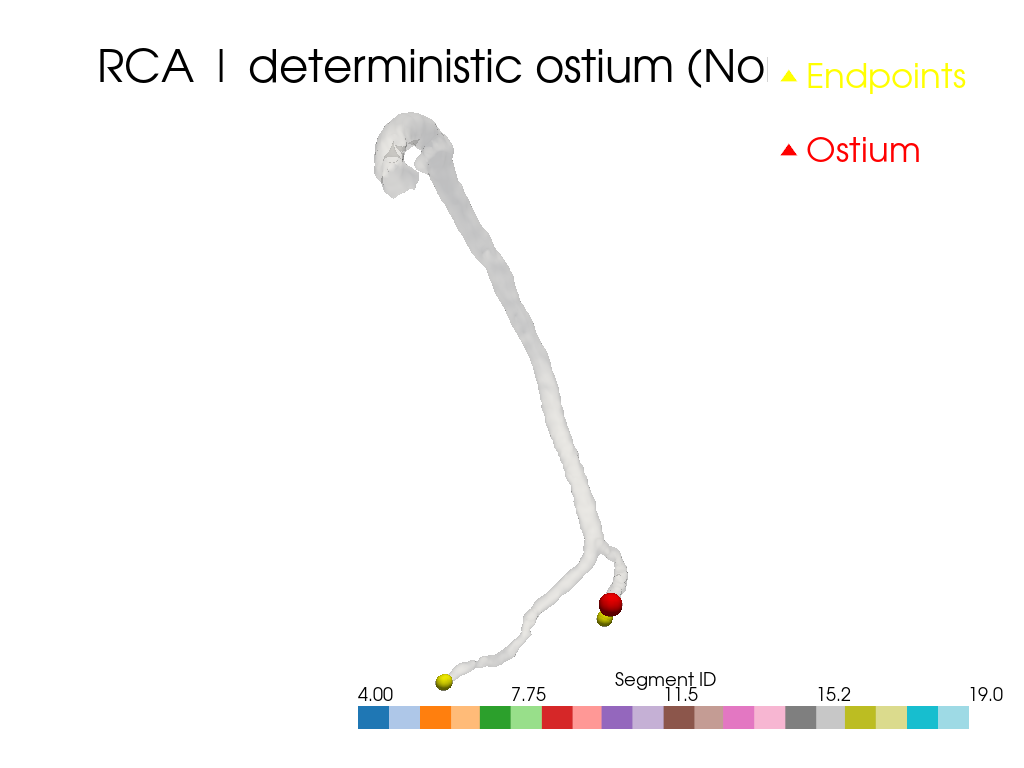

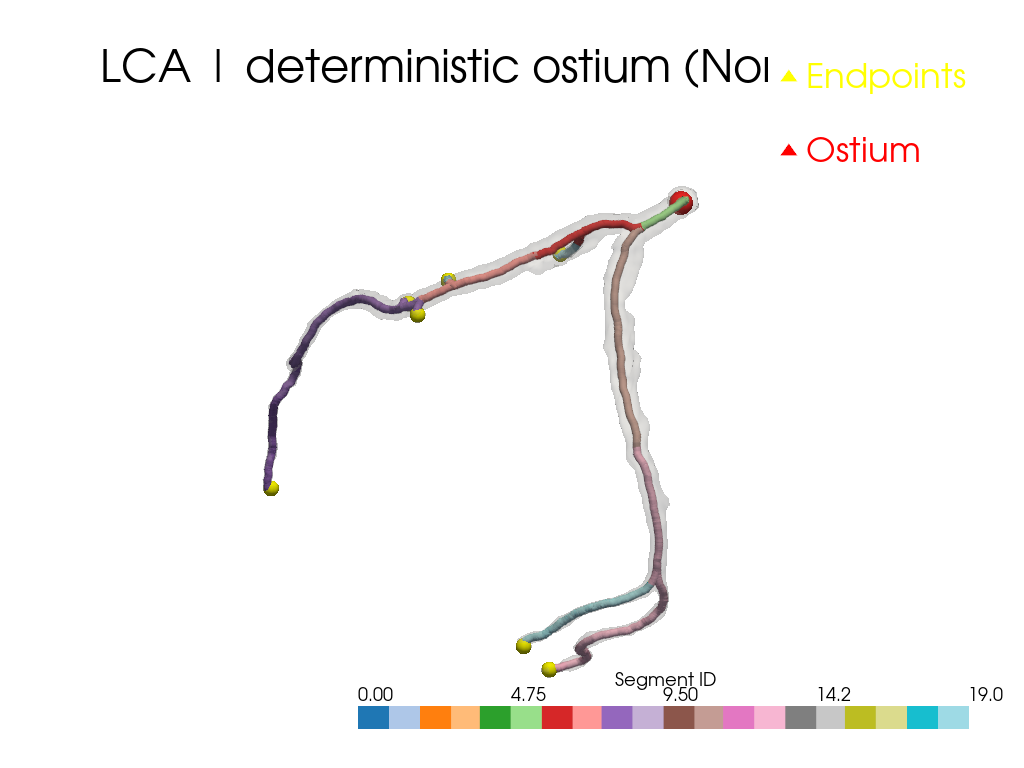

In [7]:
# Purpose: per-artery QA visualization.
for artery in ("RCA", "LCA"):
    cl = centerlines[artery]
    pts = np.asarray(cl.points, dtype=float)
    ijk_idx, _ = world_to_voxel_idx(pts)
    seg = np.array([sample_label_at_voxel(label_arr, idx) for idx in ijk_idx], dtype=int)

    cl_color = cl.copy(deep=True)
    cl_color.point_data["SegmentLabel"] = seg

    surface_path = PROJECT_ROOT / "results" / "block1_results" / sample_name / f"surface_{artery}.vtp"
    mesh = pv.read(str(surface_path))

    eps = endpoints_df[endpoints_df["Artery"] == artery][["Px", "Py", "Pz"]].to_numpy(dtype=float)
    ost = selected_ostia[artery]
    ost_pt = np.array([[ost["Px"], ost["Py"], ost["Pz"]]], dtype=float)

    pl = pv.Plotter()
    pl.add_mesh(mesh, color="lightgray", opacity=0.20, smooth_shading=True, show_edges=False)
    pl.add_mesh(
        cl_color,
        scalars="SegmentLabel",
        cmap="tab20",
        line_width=8,
        render_lines_as_tubes=True,
        scalar_bar_args={"title": "Segment ID"},
    )
    if len(eps) > 0:
        pl.add_points(eps, color="yellow", point_size=16, render_points_as_spheres=True, label="Endpoints")
    pl.add_points(ost_pt, color="red", point_size=24, render_points_as_spheres=True, label="Ostium")
    pl.add_title(f"{artery} | deterministic ostium ({sample_name})")
    pl.add_legend(bcolor="white")
    pl.show()